In [ ]:
#裁出影片的每一幀，並存成圖片檔
import cv2
import os

def extract_frames(video_path, output_folder, label):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    cap = cv2.VideoCapture(video_path)
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        # 每隔5幀存一張圖，避免數據太過重複
        if count % 5 == 0:
            cv2.imwrite(f"{output_folder}/{label}_{count}.jpg", frame)
        count += 1
    cap.release()

# 確保影片檔名正確，且順序一致
extract_frames('normal.mp4', 'dataset/train/Normal', 'normal')
extract_frames('Chatter.mp4', 'dataset/train/Chatter', 'chatter')
extract_frames('RoughCut.mp4', 'dataset/train/RoughCut', 'rough')
extract_frames('ToolBreak-1.mp4', 'dataset/train/ToolBroken', 'broken')

In [ ]:
# 訓練模型的程式碼
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# 1. 數據增強：讓少量的圖片看起來像很多圖片
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224), # 隨機裁剪，讓模型不要老是看同一個位置
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # 改變亮度對比，模擬不同光影
    transforms.RandomHorizontalFlip(), # 隨機水平翻轉
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. 載入資料
train_data = datasets.ImageFolder('dataset/train', transform=data_transforms)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

# 3. 定義模型 (ResNet18)
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4) # 四種狀態輸出

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 4. 訓練設定
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        """
        patience: 忍受幾次 Loss 沒有下降就停止
        delta: Loss 減少的最小值（低於這個值視為沒進步）
        """
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# 5. 開始訓練 
print("開始訓練...")
model.train()
early_stopper = EarlyStopping(patience=7, delta=0.001) 
epochs = 20 

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # 呼叫 EarlyStopping，數據太少0.00幾就已經在死背了
    early_stopper(avg_loss)
    if early_stopper.early_stop:
        print("偵測到模型不再進步，觸發 Early Stopping！")
        break

torch.save(model.state_dict(), 'machining_model.pth')
print("訓練完成，權重已儲存。")

正在分析影片，每 29 秒顯示一次結果...


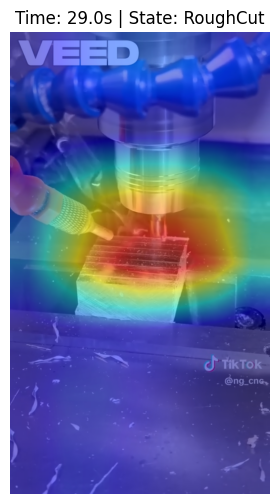

時間點 29.0s：模型辨識為 RoughCut


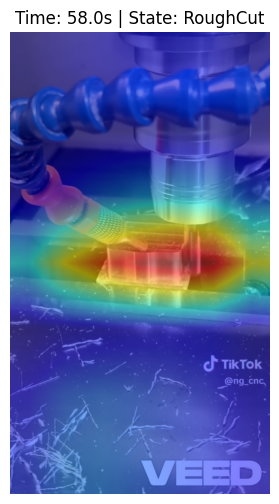

時間點 58.0s：模型辨識為 RoughCut


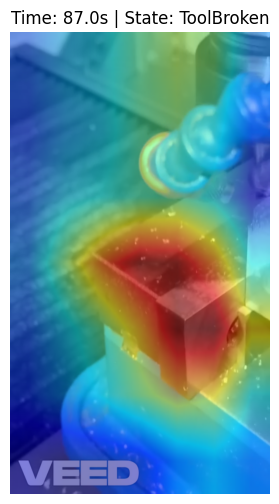

時間點 87.0s：模型辨識為 ToolBroken


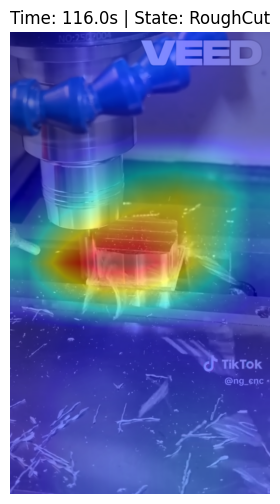

時間點 116.0s：模型辨識為 RoughCut


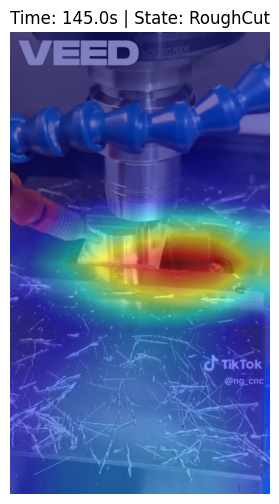

時間點 145.0s：模型辨識為 RoughCut
分析結束。


In [8]:

import torch
import numpy as np
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# 狀態清單 (順序必須與訓練時的資料夾字母順序一致)
STATES = ['Chatter', 'Normal', 'RoughCut', 'ToolBroken']

def analyze_video_in_jupyter(video_path, model_path):
    # 1. 載入模型與GradCAM設定
    model = models.resnet18()
    model.fc = torch.nn.Linear(model.fc.in_features, 4)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    target_layers = [model.layer4[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 2. 開啟影片
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    interval_seconds = 29
    interval_frames = int(fps * interval_seconds)
    
    frame_count = 0
    print(f"正在分析影片，每 {interval_seconds} 秒顯示一次結果...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        frame_count += 1

        # 只有在 30 秒的倍數時才進行運算與顯示
        if frame_count % interval_frames == 0:
            # 影像預處理
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            input_tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0)

            # 3. 取得模型預測
            with torch.no_grad():
                output = model(input_tensor)
                pred_idx = torch.argmax(output).item()
                current_state = STATES[pred_idx]

            # 4. 生成熱力圖 (Grad-CAM)
            targets = [ClassifierOutputTarget(pred_idx)]
            grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
            grayscale_cam_resized = cv2.resize(grayscale_cam, (width, height))
            
            # 疊加熱圖
            cam_image = show_cam_on_image(img_rgb.astype(np.float32) / 255, grayscale_cam_resized, use_rgb=True)
            
            # 5. 在下方顯示結果
            plt.figure(figsize=(10, 6))
            plt.imshow(cam_image)
            plt.title(f"Time: {frame_count // fps:.1f}s | State: {current_state}")
            plt.axis('off')
            plt.show() # 直接在 Cell 輸出圖片
            
            print(f"時間點 {frame_count // fps}s：模型辨識為 {current_state}")

    cap.release()
    print("分析結束。")

# 執行區
analyze_video_in_jupyter(r"D:\yang_neural_network\mid_term\TestMachining.mp4", 'normal_ephos10_machining_model.pth')

## 第一階段
每隔5幀存一張圖，避免數據太過重複，並存成圖片檔，供第二階段做訓練

## 第二階段
資料增強(用出更多樣的訓練資料)，採用resnet18將最後一層分類改成4個狀態，以防overfitting故設earlystopping

## 第三階段
實作

## 結論
熱力圖（紅色區域）精準落在刀具與工件接觸的切削點上，模型透過觀察切削時產生的特徵（如切屑、火花或切削路徑）